In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
import collections
import random
import pandas as pd
import datetime
import scipy as sci
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import torch
from matplotlib.patches import PathPatch
from matplotlib.path import Path


In [2]:
### define functions for numerical solution ###

N=40 #number of agents
v0=2

lambda1 = 1.999E-01
lambda2 = -1.345E-01
lambda3 = -1.015E-01
lambda4 = 1.146E-01
power1 = -9.288E-02
power2 = 1.826E-01
power3 = 1.322E-01

lambda1_v = -1.026E-01
lambda2_v = -3.282E-01
lambda3_v = -1.597E-01
lambda4_v = 4.405E-01
power1_v = -2.314E-01
power2_v = -3.216E-01
power3_v = -2.862E-01
int_range = 2



def wall_interaction(pos):
    x, y = pos
    F = np.zeros(2)

    # Left wall
    d_left = x + box_half_length
    if d_left < wall_margin:
        d = d_left
        F[0] += 1 / (d**2)

    # Right wall
    d_right = box_half_length - x
    if d_right < wall_margin:
        d = d_right
        F[0] -= 1 / (d**2)

    # Bottom wall
    d_bottom = y + box_half_length
    if d_bottom < wall_margin:
        d = d_bottom
        F[1] += 1 / (d**2)

    # Top wall
    d_top = box_half_length - y
    if d_top < wall_margin:
        d = d_top
        F[1] -= 1 / (d**2)

    return F


def obstacle_interaction(pos, margin=1.0):
    F = np.zeros(2)
    for i, center in enumerate(obstacle_positions):
        r_o = obstacle_radii[i]
        diff = pos - center
        dist = np.linalg.norm(diff)
        d = dist - r_o  # Distance to obstacle boundary = center-to-center distance - radius

        if d < margin:
            F_io_dir = diff / dist          # Direction unit vector
            F += F_io_dir / (d**2)          # Magnitude: inversely proportional to square of distance

    return F

def total_infer_x(s, i):
    n_array = np.array(n)
    self_index = np.repeat(i, n - 1)
    others_index = list(range(n))
    others_index.remove(i)

    x1 = np.take(s, self_index)
    y1 = np.take(s, self_index + n_array)
    x2 = np.take(s, others_index)
    y2 = np.take(s, others_index + n_array)
    dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

    vi_x = np.take(s, 2*n_array + self_index)
    vi_y = np.take(s, 3*n_array + self_index)
    vj_x = np.take(s, 2*n_array + others_index)
    vj_y = np.take(s, 3*n_array + others_index)
    vel_rel = np.sqrt((vi_x - vj_x)**2 + (vi_y - vj_y)**2)

    local_dist_func = np.heaviside(int_range - dist, 1)

    F_int_x = (x1 - x2)/dist * (lambda1*(dist**power1) + lambda2*(dist**power2) + lambda3*(dist**power3) + lambda4) + \
              (vi_x - vj_x)/vel_rel * (lambda1_v*(dist**power1_v) + lambda2_v*(dist**power2_v) + lambda3_v*(dist**power3_v) + lambda4_v) * local_dist_func

    total_interaction_x = sum(F_int_x)

    v_i_x = s[2*n + i]
    v_i_y = s[3*n + i]
    v_i_mag = np.sqrt(v_i_x**2 + v_i_y**2)
    self_propel_x = (v_i_x / v_i_mag) * (v0 - v_i_mag)

    pos_i = np.array([s[i], s[i + n]])
    obs_force_x = obstacle_interaction(pos_i, obs_margin)[0] + wall_interaction(pos_i)[0]

    return self_propel_x + total_interaction_x + obs_force_x


def total_infer_y(s, i):
    n_array = np.array(n)
    self_index = np.repeat(i, n - 1)
    others_index = list(range(n))
    others_index.remove(i)

    x1 = np.take(s, self_index)
    y1 = np.take(s, self_index + n_array)
    x2 = np.take(s, others_index)
    y2 = np.take(s, others_index + n_array)
    dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

    vi_x = np.take(s, 2*n_array + self_index)
    vi_y = np.take(s, 3*n_array + self_index)
    vj_x = np.take(s, 2*n_array + others_index)
    vj_y = np.take(s, 3*n_array + others_index)
    vel_rel = np.sqrt((vi_x - vj_x)**2 + (vi_y - vj_y)**2)

    local_dist_func = np.heaviside(int_range - dist, 1)

    F_int_y = (y1 - y2)/dist * (lambda1*(dist**power1) + lambda2*(dist**power2) + lambda3*(dist**power3) + lambda4) + \
              (vi_y - vj_y)/vel_rel * (lambda1_v*(dist**power1_v) + lambda2_v*(dist**power2_v) + lambda3_v*(dist**power3_v) + lambda4_v) * local_dist_func

    total_interaction_y = sum(F_int_y)

    v_i_x = s[2*n + i]
    v_i_y = s[3*n + i]
    v_i_mag = np.sqrt(v_i_x**2 + v_i_y**2)
    self_propel_y = (v_i_y / v_i_mag) * (v0 - v_i_mag)

    pos_i = np.array([s[i], s[i + n]])
    obs_force_y = obstacle_interaction(pos_i, obs_margin)[1] + wall_interaction(pos_i)[1]

    return self_propel_y + total_interaction_y + obs_force_y



def F_infer_ivp(t,s):
    return np.concatenate((s[2*n:3*n],s[3*n:4*n],\
                           [total_infer_x(s,i) for i in range(n)]+np.random.normal(0,10,size=n), 
                           [total_infer_y(s,i) for i in range(n)]+np.random.normal(0,10,size=n)))


In [3]:
###### Wall visualization function ########


def add_hollow_rectangle(ax, outer_half_length, inner_half_length, facecolor='green', **kwargs):
    # Outer rectangle coordinates (counterclockwise)
    outer = [
        (-outer_half_length, -outer_half_length),
        (-outer_half_length,  outer_half_length),
        ( outer_half_length,  outer_half_length),
        ( outer_half_length, -outer_half_length),
        (-outer_half_length, -outer_half_length)
    ]

    # Inner rectangle coordinates (must be clockwise to be recognized as a hole)
    inner = [
        (-inner_half_length, -inner_half_length),
        ( inner_half_length, -inner_half_length),
        ( inner_half_length,  inner_half_length),
        (-inner_half_length,  inner_half_length),
        (-inner_half_length, -inner_half_length)
    ]

    vertices = outer + inner
    codes = (
        [Path.MOVETO] + [Path.LINETO]*3 + [Path.CLOSEPOLY] +
        [Path.MOVETO] + [Path.LINETO]*3 + [Path.CLOSEPOLY]
    )

    path = Path(vertices, codes)
    patch = PathPatch(path, facecolor=facecolor, edgecolor='none', **kwargs)
    ax.add_patch(patch)


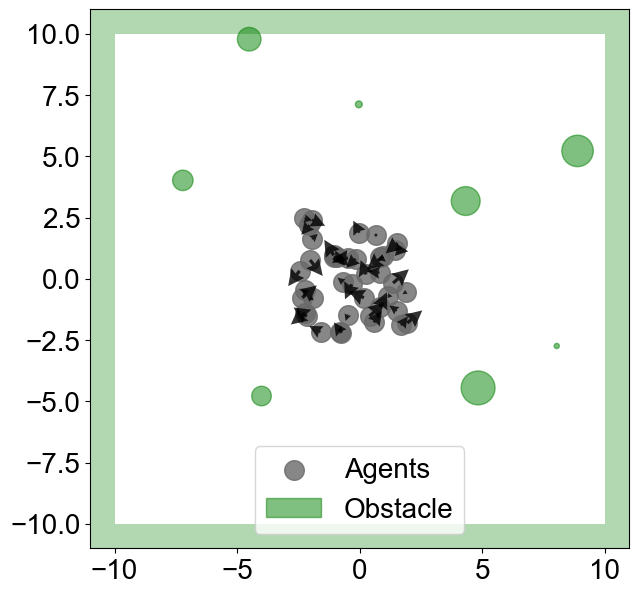

In [4]:
plt.rc('font', size=20, family='Arial')

########## WALL DEFINITION ##########
box_half_length = 10     # Square box domain: [-10, 10] × [-10, 10]
wall_margin = 1.0        # Minimum placement margin near the walls


########## OBSTACLE DEFINITION & INITIAL AGENT CONDITIONS ##########
range_init = 2.5
position_list_x = []
position_list_y = []
velocity_list_x = []
velocity_list_y = []

random.seed(101)

# Random initial positions and velocities for agents
for i in range(40):
    position_list_x.append(random.uniform(-range_init, range_init))
    position_list_y.append(random.uniform(-range_init, range_init))
    velocity_list_x.append(random.uniform(-1.0, 1.0))
    velocity_list_y.append(random.uniform(-1.0, 1.0))

num_obstacles = 8
obs_margin = 1.0
arena_size = 10
obstacle_seed = 146
np.random.seed(obstacle_seed)

obstacle_positions = []
obstacle_radii = []

# Ensure obstacle is placed outside agent area
def is_outside_agent_area(x, y, margin=range_init):
    return abs(x) > margin or abs(y) > margin  # Valid if either x or y is outside agent area

while len(obstacle_positions) < num_obstacles:
    x, y = np.random.uniform(-arena_size, arena_size, size=2)
    if is_outside_agent_area(x, y):
        obstacle_positions.append([x, y])
        obstacle_radii.append(np.random.uniform(0.1, 1.0))

obstacle_positions = np.array(obstacle_positions)
obstacle_radii = np.array(obstacle_radii)


########## STATE VECTOR CONSTRUCTION ##########
nodes_np = np.array([position_list_x, position_list_y, velocity_list_x, velocity_list_y], dtype=np.float32)
s0 = nodes_np.reshape(-1)
n = nodes_np.shape[1]


########## VISUALIZATION OF INITIAL POSITIONS AND VELOCITIES ##########

# Define colors
agent_color = np.array([105./255, 105./255, 105./255, 0.8])
init_color = np.array([0., 0., 0.])  # Default color when no rotation color is used

fig, ax = plt.subplots(figsize=(7, 7))

# Plot initial agent positions
ax.scatter(position_list_x, position_list_y, color=agent_color, s=200, label='Agents')

# Plot velocity vectors using quiver
origin = np.array([position_list_x, position_list_y])
velocity_array = np.array([velocity_list_x, velocity_list_y])
quiver_color = [np.append(init_color, 0.8) for _ in range(N)]

plt.quiver(*origin, velocity_array[0], velocity_array[1],
           scale_units='xy', angles='xy', color=quiver_color,
           scale=1.5, width=0.006, headwidth=5, zorder=2)

########## OBSTACLE VISUALIZATION ##########
for pos, r in zip(obstacle_positions, obstacle_radii):
    circle = plt.Circle(pos, r, color='green', alpha=0.5, label='Obstacle')
    ax.add_patch(circle)

########## WALL VISUALIZATION (HOLLOW RECTANGLE) ##########
padding = 1
outer_half = box_half_length + padding
inner_half = box_half_length
add_hollow_rectangle(ax, outer_half, inner_half, facecolor='green', alpha=0.3, zorder=0)

# Plot settings
ax.set_aspect('equal')
ax.set_xlim(-outer_half, outer_half)
ax.set_ylim(-outer_half, outer_half)

# Legend (remove duplicates)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.show()


In [5]:
np.random.seed(11)
dt=0.1
T=100
t=np.arange(0,T+dt,dt)

solution=solve_ivp(F_infer_ivp,[0,T],s0, method='RK45', max_step= 0.01, t_eval=t)

print(solution)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-01 ...  9.990e+01  1.000e+02]
        y: [[ 4.058e-01  4.919e-01 ... -1.086e+00 -9.584e-01]
            [-1.643e-01 -2.228e-01 ... -1.100e+00 -9.731e-01]
            ...
            [-4.517e-01 -5.031e-01 ...  1.480e+00  1.434e+00]
            [ 7.154e-01  6.660e-01 ...  1.929e+00  1.778e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 3413588
     njev: 0
      nlu: 0


C:\Users\user\AppData\Local\Temp\ipykernel_10092\22242649.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap1 = plt.cm.get_cmap('jet', 40)


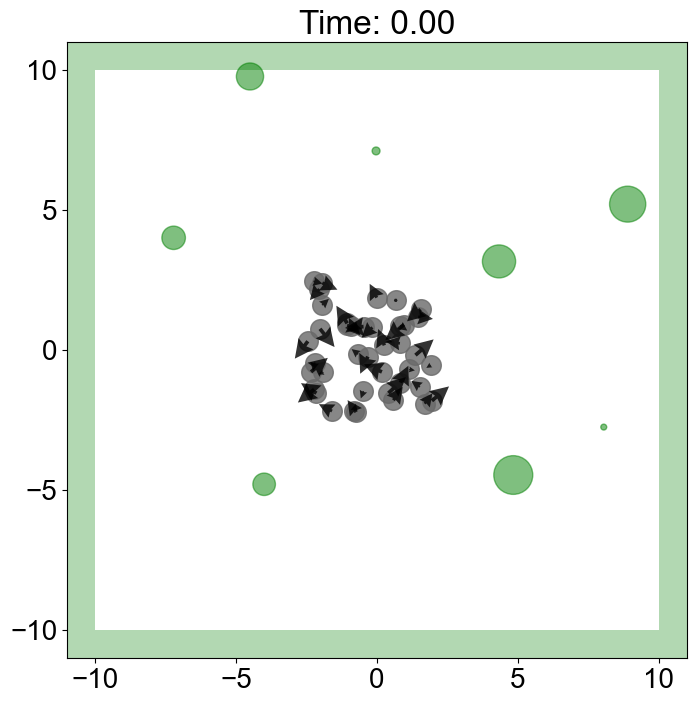

In [6]:
import matplotlib.animation as animation

solution_plot = np.transpose(solution.y)

plt.rc('font', family='Arial', size=20)
speed = 1
t_plot = np.arange(0, T + dt * speed, dt * speed)
h = solution_plot[:, 0:2*n]
velocity = solution_plot[:, 2*n:4*n]

fig = plt.figure(figsize=(8, 8))
ax = plt.axes()
cmap1 = plt.cm.get_cmap('jet', 40)

tail_length = 10

############################### ORDER PARAMETER ###############################
velocity_x = velocity[:, 0:n]
velocity_y = velocity[:, n:]
center_x = np.mean(h[:, 0:n], axis=1, keepdims=True)
center_y = np.mean(h[:, n:], axis=1, keepdims=True)
r_x, r_y = h[:, 0:n] - center_x, h[:, n:] - center_y

r_mag = np.sqrt(np.square(r_x) + np.square(r_y))
vel_mag = np.sqrt(np.square(velocity_x) + np.square(velocity_y))  # N × V
vel_mag_sum = np.sum(vel_mag, axis=1)

vel_x_sum = np.sum(velocity_x, axis=1)
vel_y_sum = np.sum(velocity_y, axis=1)
vel_vec_mag = np.sqrt(np.square(vel_x_sum) + np.square(vel_y_sum))  # Magnitude of net velocity

order_para = vel_vec_mag / vel_mag_sum
ang_mom = r_x * velocity_y - r_y * velocity_x

denom = np.sum(r_mag * vel_mag, axis=1)
ang_mom_sum = np.abs(np.sum(ang_mom, axis=1))
ang_mom_abs = np.sum(np.abs(ang_mom), axis=1)

order_para_rot = ang_mom_sum / denom
order_para_rot_abs = ang_mom_abs / denom

##########################################################################
init_color = np.array([0., 0., 0.])
cw_color = np.array([0., 100., 250.])
ccw_color = np.array([240., 84., 0.])
flock_color = np.array([145., 84., 192.])
agent_color = np.array([105./255, 105./255, 105./255, 0.8])

############################### ANIMATION FUNCTION ###############################

def animate(i):
    window = 10
    ax.clear()

    if i >= len(t_plot):  # Keep displaying the last frame after simulation ends
        i = len(t_plot) - 1

    ##### OBSTACLE VISUALIZATION #####
    for k in range(len(obstacle_positions)):
        obstacle_circle = plt.Circle(
            obstacle_positions[k],
            obstacle_radii[k],
            color='green',
            alpha=0.5,
            zorder=0
        )
        ax.add_patch(obstacle_circle)

    ##### WALL VISUALIZATION (hollow rectangle) #####
    padding = 1
    outer_half = box_half_length + padding
    inner_half = box_half_length
    add_hollow_rectangle(ax, outer_half, inner_half, facecolor='green', alpha=0.3, zorder=0)

    ##### AGENT POSITIONS AND TRAILS #####
    plt.scatter(h[i*speed, 0:n], h[i*speed, n:], color=agent_color, s=200, zorder=0)
    for j in range(n):
        ax.plot(h[i*speed - tail_length:i*speed+1, j],
                h[i*speed - tail_length:i*speed+1, n+j],
                '--', c=agent_color, lw=1, ms=1)

    ##### VELOCITY VECTORS (quiver) #####
    rot_color = []
    for ii in range(len(ang_mom[i*speed, :])):
        if order_para[i*speed] > 0.7:
            rot_color.append(np.append(flock_color * (order_para[i*speed] - 0.7) / 0.3 / 255, [0.8]))
        else:
            rot_color.append(np.append(init_color, [0.8]))

    origin = np.array([h[i*speed, 0:n], h[i*speed, n:]])
    plt.quiver(*origin, velocity[i*speed, 0:n], velocity[i*speed, n:],
               scale_units='xy', angles='xy', color=rot_color,
               scale=1.5, width=0.006, headwidth=5, zorder=2)

    ##### FIXED CAMERA VIEW #####
    center_x_i = np.mean(h[i*speed, 0:n])
    center_y_i = np.mean(h[i*speed, n:])
    ax.set_title('Time: {:.2f}'.format(t[i*speed]))
    ax.set_xticks(np.arange(-100, 100, 5))
    ax.set_yticks(np.arange(-100, 100, 5))
    ax.set_xlim(-outer_half, outer_half)
    ax.set_ylim(-outer_half, outer_half)

# Run the animation
anim = animation.FuncAnimation(fig, animate, frames=len(t_plot) + 5)

from IPython.display import HTML
HTML(anim.to_html5_video())


(-11.0, 11.0)

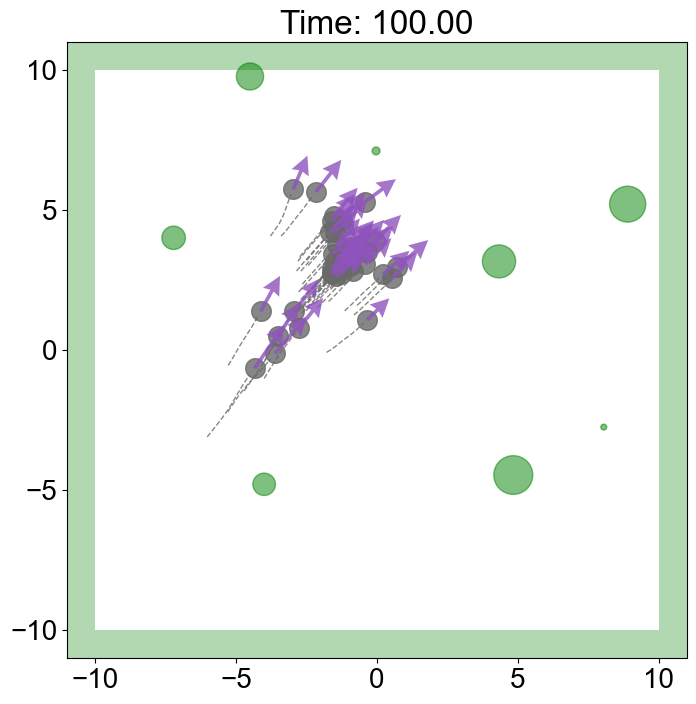

In [7]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes()

#### OBSTACLE VISUALIZATION #####
for k in range(len(obstacle_positions)):
    obstacle_circle = plt.Circle(
        obstacle_positions[k],
        obstacle_radii[k],
        color='green',
        alpha=0.5,
        zorder=0
    )
    ax.add_patch(obstacle_circle)

##### WALL VISUALIZATION (hollow rectangle) #####
padding = 1
outer_half = box_half_length + padding
inner_half = box_half_length
add_hollow_rectangle(ax, outer_half, inner_half, facecolor='green', alpha=0.3, zorder=0)

##### AGENT POSITIONS AND TRAILS #####
plt.scatter(h[-1, 0:n], h[-1, n:], color=agent_color, s=200, zorder=0)
for j in range(n):
    ax.plot(h[-11:-1, j],
            h[-11:-1, n+j],
            '--', c=agent_color, lw=1, ms=1)

##### VELOCITY VECTORS (quiver) #####
rot_color = []
for ii in range(len(ang_mom[-1, :])):
    if order_para[-1] > 0.7:
        rot_color.append(np.append(flock_color * (order_para[-1] - 0.7) / 0.3 / 255, [0.8]))
    else:
        rot_color.append(np.append(init_color, [0.8]))

origin = np.array([h[-1, 0:n], h[-1, n:]])
plt.quiver(*origin, velocity[-1, 0:n], velocity[-1, n:],
           scale_units='xy', angles='xy', color=rot_color,
           scale=1.5, width=0.006, headwidth=5, zorder=2)


##### FIXED CAMERA VIEW #####
center_x_i = np.mean(h[-1, 0:n])
center_y_i = np.mean(h[-1, n:])
ax.set_title('Time: {:.2f}'.format(t[-1]))
ax.set_xticks(np.arange(-100, 100, 5))
ax.set_yticks(np.arange(-100, 100, 5))
ax.set_xlim(-outer_half, outer_half)
ax.set_ylim(-outer_half, outer_half)